# Projecte Final: Anàlisi del finançament de les administracions públiques de Catalunya als mitjans de comunicació (2015-2024)

## Notebook 03 — Visualitzacions i anàlisi estadístic

Carregarem taules mestres netes "menjometre_totals_anuals_admin.csv" i "menjometre_detallat_enriquit_admin.csv" i realitzem visualitzacions per fer l'anàlisi de dades

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import squarify
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.gridspec as gridspec
from adjustText import adjust_text 
from scipy import stats



In [2]:

# Carreguem Dataframes
df_totals = pd.read_csv("menjometre_totals_anuals_admin.csv", encoding="utf-8-sig")
df_detall = pd.read_csv("menjometre_detallat_enriquit_admin.csv",      encoding="utf-8-sig")

print("df_totals:", df_totals.shape)
print("df_detall:", df_detall.shape)
print()


df_totals: (11, 5)
df_detall: (974, 21)



###1.  Quina ha estat l'evolució anual del finançament públic als mitjans de comunicació?


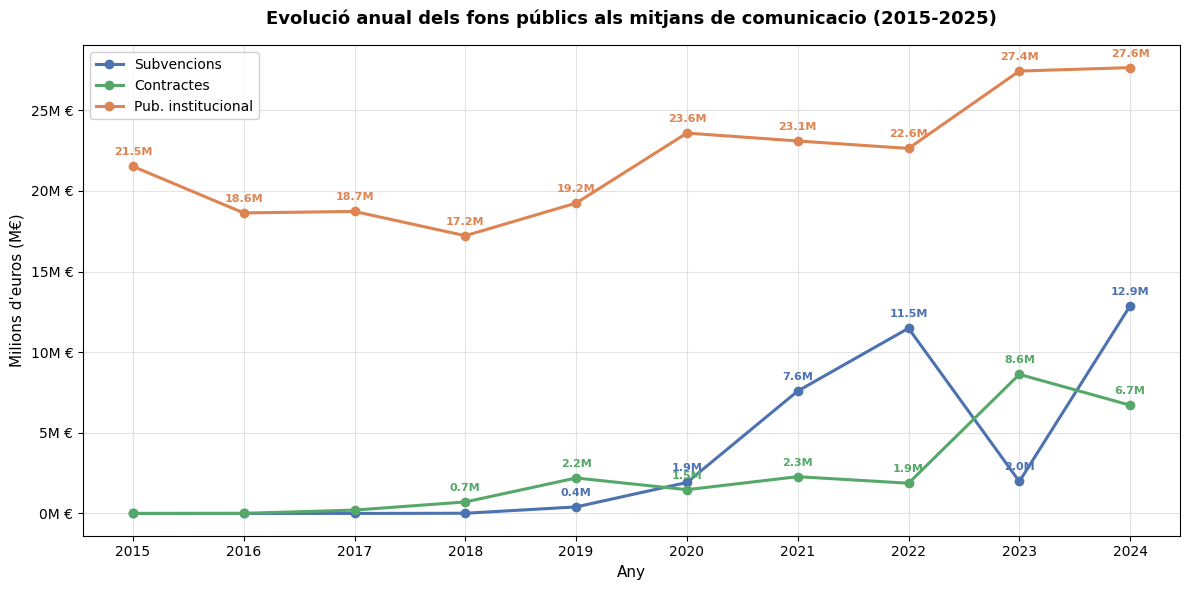

Gràfic guardat: grafic_linies_fons_premsa.png


In [3]:
# ── Preparació de les dades (idèntica a l'original) ──
df_plot = df_totals[(df_totals['Any'] >= 2015) & (df_totals['Any'] <= 2024)]
df_plot = df_plot.sort_values("Any")

df_plot["Subvencions_M"]       = df_plot["Subvencions"]       / 1_000_000
df_plot["Contractes_M"]        = df_plot["Contractes"]        / 1_000_000
df_plot["Pub_institucional_M"] = df_plot["Pub. institucional"] / 1_000_000

anys = df_plot["Any"].astype(str).tolist()
subv = df_plot["Subvencions_M"].tolist()
cont = df_plot["Contractes_M"].tolist()
pub  = df_plot["Pub_institucional_M"].tolist()

x = np.arange(len(anys))

# ── Dibuix (línies en lloc de barres) ──
fig, ax = plt.subplots(figsize=(12, 6))

linia_subv, = ax.plot(x, subv, marker="o", linewidth=2.2, color="#4C72B0", label="Subvencions")
linia_cont, = ax.plot(x, cont, marker="o", linewidth=2.2, color="#55A868", label="Contractes")
linia_pub,  = ax.plot(x, pub,  marker="o", linewidth=2.2, color="#DD8452", label="Pub. institucional")

# ── Etiquetes de valor a cada punt ──
for xi, valor in zip(x, subv):
    if valor > 0.3:
        ax.annotate(f"{valor:.1f}M", (xi, valor), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8, color="#4C72B0", fontweight="bold")

for xi, valor in zip(x, cont):
    if valor > 0.3:
        ax.annotate(f"{valor:.1f}M", (xi, valor), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8, color="#55A868", fontweight="bold")

for xi, valor in zip(x, pub):
    if valor > 0.3:
        ax.annotate(f"{valor:.1f}M", (xi, valor), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontsize=8, color="#DD8452", fontweight="bold")

# ── Format (idèntic a l'original) ──
ax.set_title("Evolució anual dels fons públics als mitjans de comunicacio (2015-2025)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Any", fontsize=11)
ax.set_ylabel("Milions d'euros (M€)", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(anys, rotation=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}M €"))
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig("grafic_linies_fons_premsa.png", dpi=150)
plt.show()
print("Gràfic guardat: grafic_linies_fons_premsa.png")

### 2. Com ha estat la distribució dels diners rebuts per mitjà?



Files per al boxplot: 961
Anys coberts: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Entitats úniques: 186



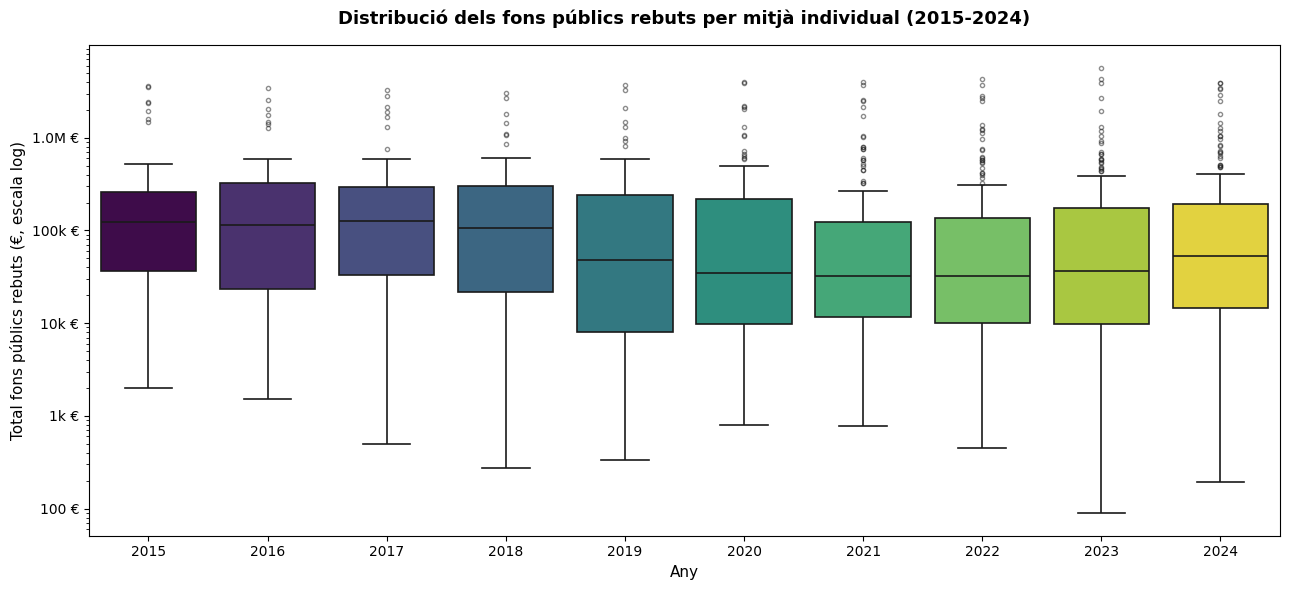

Gràfic guardat: grafic_boxplot_fons_per_mitja.png


In [4]:


df_box = df_detall.copy()
df_box = df_box[(df_box["CIF"] != "") & (df_box["CIF"].notna())] # Filtre 1: només entitats individuals (les que tenen CIF)
df_box = df_box[(df_box["Any"] >= 2015) & (df_box["Any"] <= 2024)] # Filtre 2: anys 2015-2024 (excloem 2025, dades incompletes)
df_box = df_box[df_box["Total"] > 0]   # excloem zeros (sense finançament aquell any)

print(f"Files per al boxplot: {len(df_box)}")
print(f"Anys coberts: {sorted(df_box['Any'].unique())}")
print(f"Entitats úniques: {df_box['CIF'].nunique()}")
print()

# ── Dibuix ──
fig, ax = plt.subplots(figsize=(13, 6))

sns.boxplot(
    data=df_box,
    x="Any",
    y="Total",
    hue="Any",
    palette="viridis",
    legend=False,
    ax=ax,
    # Mostrem els outliers com a punts petits
    flierprops=dict(marker="o", markersize=3, alpha=0.5, color="gray"),
    linewidth=1.2
)

# Escala logarítmica (imprescindible: hi ha entitats amb 500€ i altres amb 7M€) Si tens números que van d'\(1\) fins a \(100.000\), 
ax.set_yscale("log")

# Formatador de l'eix Y en euros llegibles
def format_euros(x, _):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M €"
    if x >= 1_000:
        return f"{x/1_000:.0f}k €"
    return f"{x:.0f} €"

ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_euros))

ax.set_title("Distribució dels fons públics rebuts per mitjà individual (2015-2024)",fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Any", fontsize=11)
ax.set_ylabel("Total fons públics rebuts (€, escala log)", fontsize=11)

plt.tight_layout()
plt.savefig("grafic_boxplot_fons_per_mitja.png", dpi=150)
plt.show()
print("Gràfic guardat: grafic_boxplot_fons_per_mitja.png")


**Interpretació**

"El boxplot temporal (2015-2024) demostra de manera gràfica una asimetria positiva extrema en la distribució del finançament públic. La pràctica totalitat dels beneficiaris es concentra en valors inferiors al milió d'euros (caixes aplanades a la base), mentre que el gruix del pressupost es desvia cap a una elit de valors atípics (outliers) que, especialment a partir de 2021, s'enfilen fins a assolir pics d'entre 6 i 8 milions d'euros per entitat,són els mitjans "grans" de mercat (com el Grup Godó o Prensa Ibérica en premsa, o la CCMA en ràdio i TV)"

### 3. ¿Quina ha estat la distribució Subvencions, Contractes i Pub. institucional, ANY A ANY (2021-2024)

In [5]:
sub20_24 = df_detall[(df_detall['Any'] >= 2021) & (df_detall['Any'] <= 2024)]

## transforme df
long_df = sub20_24.melt(
    id_vars=['Any', 'Nom_comercial'],
    value_vars=['Subvencions', 'Contractes', 'Pub. institucional'],var_name='Concepte', value_name='Import'
) 
long_df = long_df[long_df['Import'] > 0] ##Eliminem imports = 0
long_df['Any'] = long_df['Any'].astype(int)

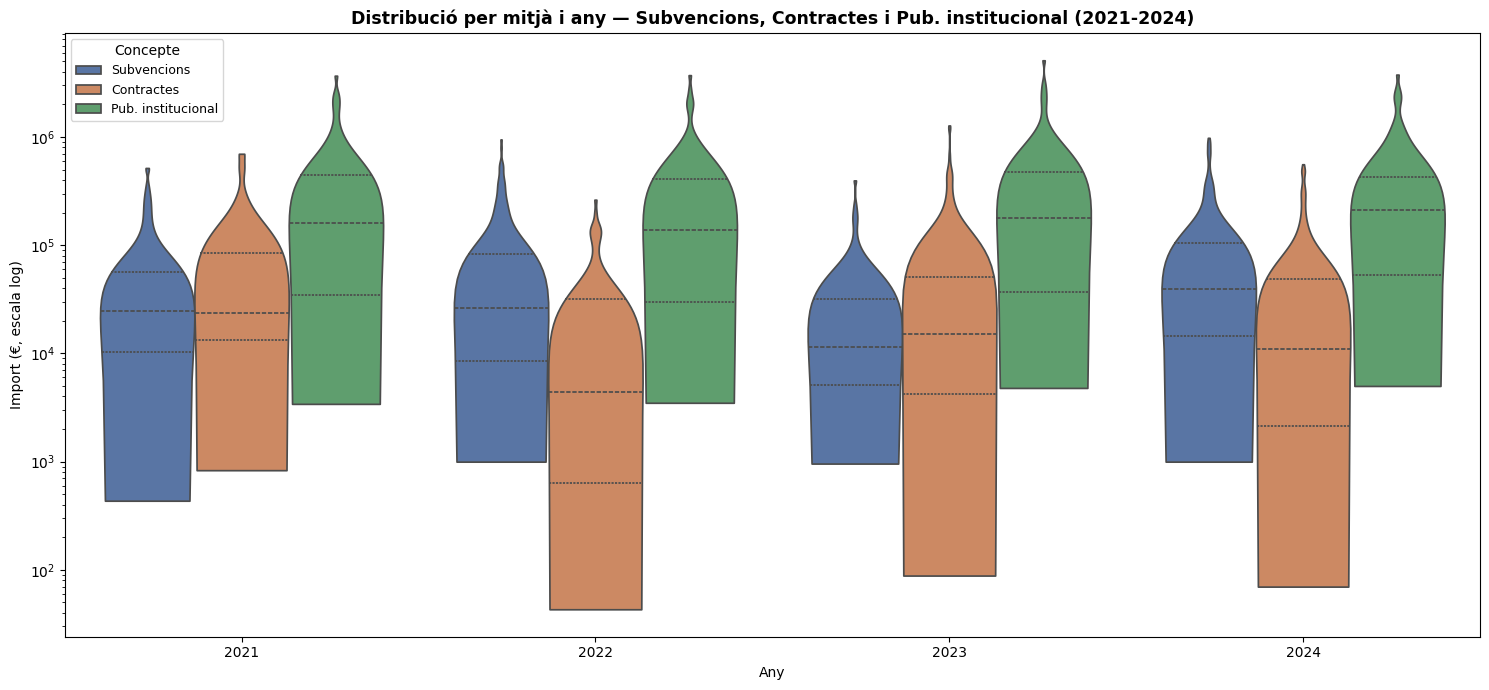

In [6]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.violinplot(
    data=long_df, x='Any', y='Import', hue='Concepte', ax=ax,
    palette=['#4C72B0', '#DD8452', '#55A868'],
    cut=0, inner='quartile', density_norm='width'
)
ax.set_yscale('log') ## Fem escala logaritmica que comprimeix els valors grans i dona més espai als petits, fent visibles tots dos extrems.
ax.set_ylabel('Import (€, escala log)')
ax.set_xlabel('Any')
ax.set_title('Distribució per mitjà i any — Subvencions, Contractes i Pub. institucional (2021-2024)',
             fontweight='bold', fontsize=12.5)
ax.legend(title='Concepte', loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('violin_per_any.png', dpi=150)
plt.show()

**Interpretació**

La publicitat institucional és el concepte amb imports més elevats i amb una distribució més concentrada en valors alts.
Les subvencions mostren una distribució més homogènia i estable entre els diferents anys.
Els contractes públics presenten la major dispersió, coexistint molts imports molt baixos amb alguns de molt elevats.
No s'observen canvis importants entre 2021 i 2024, de manera que el patró general de distribució es manté estable.
Les tres distribucions són fortament asimètriques, fet que indica que una part reduïda dels mitjans concentra una proporció significativa dels recursos públics.


### 4. Quina ha estat el total i l'evolució Top 15 Mitjans per Publicitat institucional (2015-2024)?

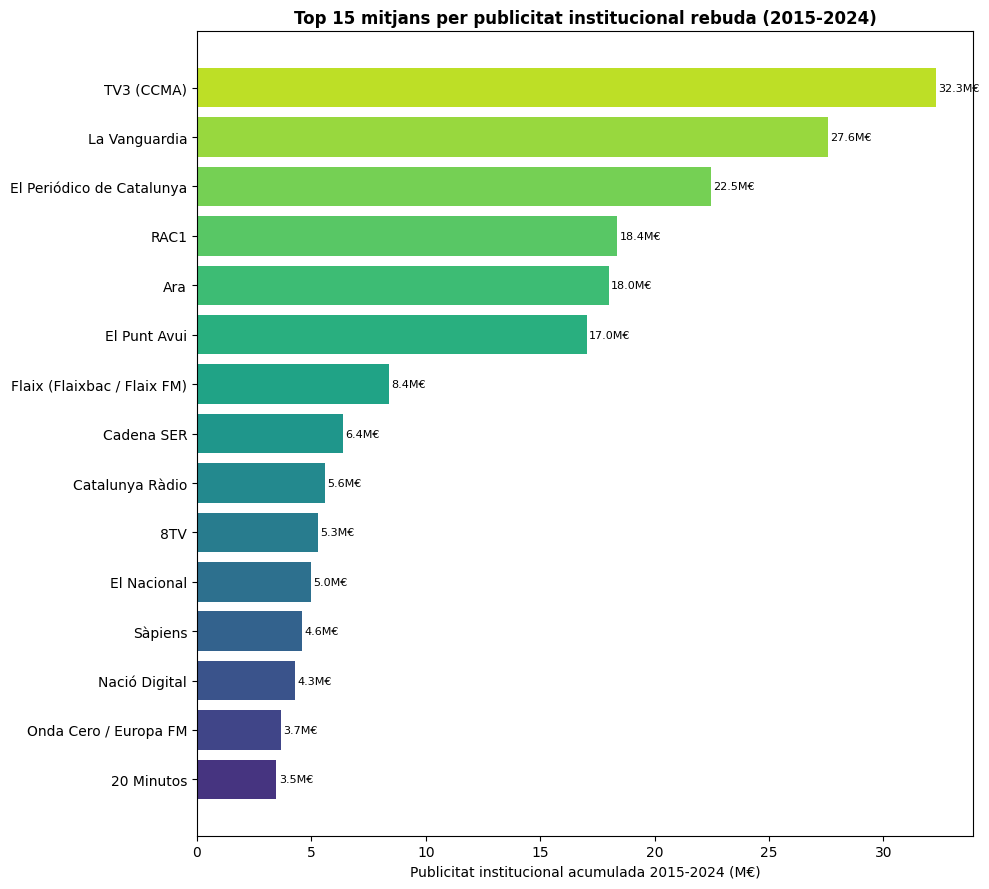

In [7]:
top15 = df_detall.groupby('Nom_comercial')['Pub. institucional'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(top15)))
ax.barh(top15.index[::-1], top15.values[::-1] / 1e6, color=colors)
ax.set_xlabel('Publicitat institucional acumulada 2015-2024 (M€)')
ax.set_title('Top 15 mitjans per publicitat institucional rebuda (2015-2024)', fontweight='bold')
for i, (n, v) in enumerate(zip(top15.index[::-1], top15.values[::-1])):
    ax.text(v / 1e6 + 0.1, i, f'{v/1e6:.1f}M€', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('g2a_barres_top15_pubinst.png', dpi=150)
plt.show()

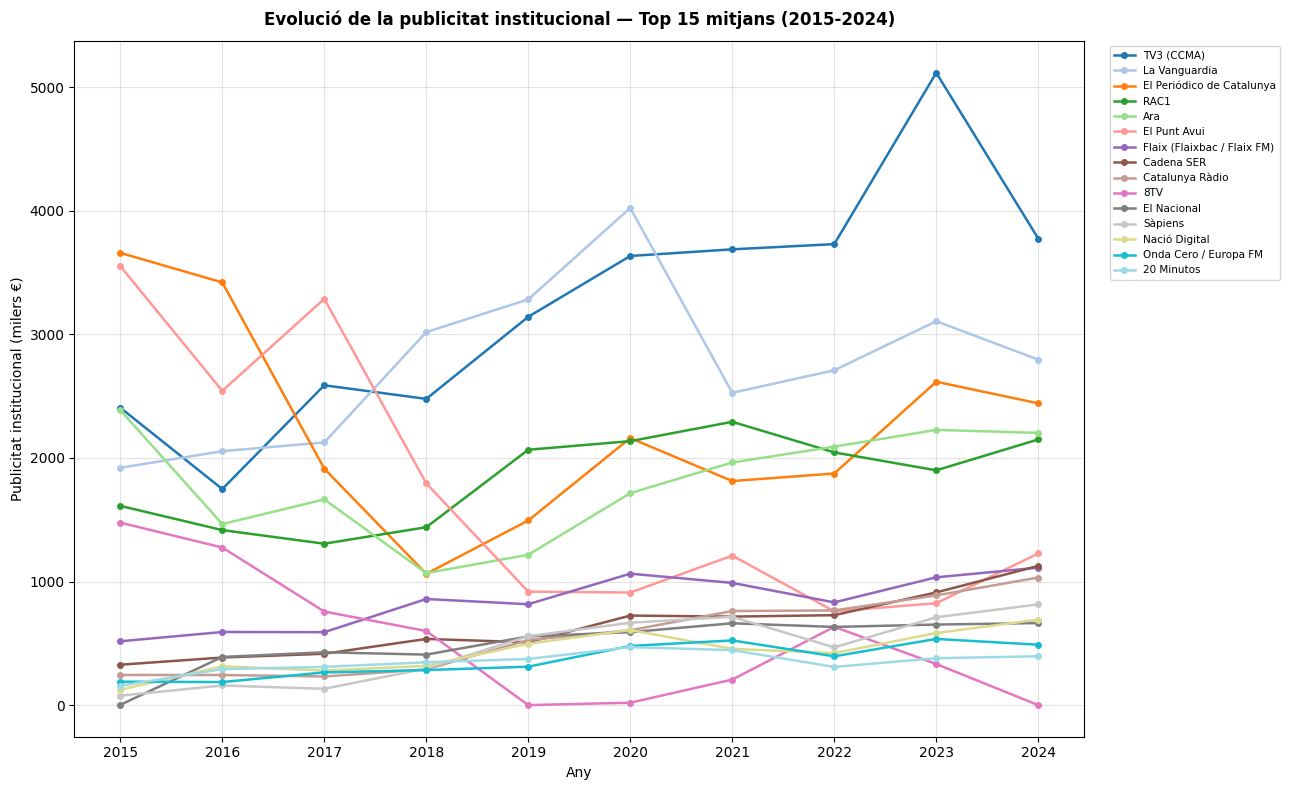

In [8]:
top15_noms = (df_detall.groupby('Nom_comercial')['Pub. institucional']
              .sum().sort_values(ascending=False).head(15).index.tolist())

pivot15 = (df_detall[df_detall['Nom_comercial'].isin(top15_noms)]
           .groupby(['Any', 'Nom_comercial'])['Pub. institucional']
           .sum().unstack(fill_value=0) / 1000)
pivot15 = pivot15[top15_noms]  # mantenir l'ordre per rellevància

fig, ax = plt.subplots(figsize=(13, 8))
colors = plt.cm.tab20(np.linspace(0, 1, 15))
for i, col in enumerate(pivot15.columns):
    ax.plot(pivot15.index, pivot15[col], marker='o', markersize=4,
            linewidth=1.8, color=colors[i], label=col)
ax.set_xlabel('Any'); ax.set_ylabel('Publicitat institucional (milers €)')
ax.set_title('Evolució de la publicitat institucional — Top 15 mitjans (2015-2024)',
             fontweight='bold', pad=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7.5)
ax.set_xticks(sorted(df_detall['Any'].unique()))
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('g3_top15_evolucio.png', dpi=150)
plt.show()


### 5. Quina ha estat l'evolució de la publicitat institucional segons el tipus de mitjà?

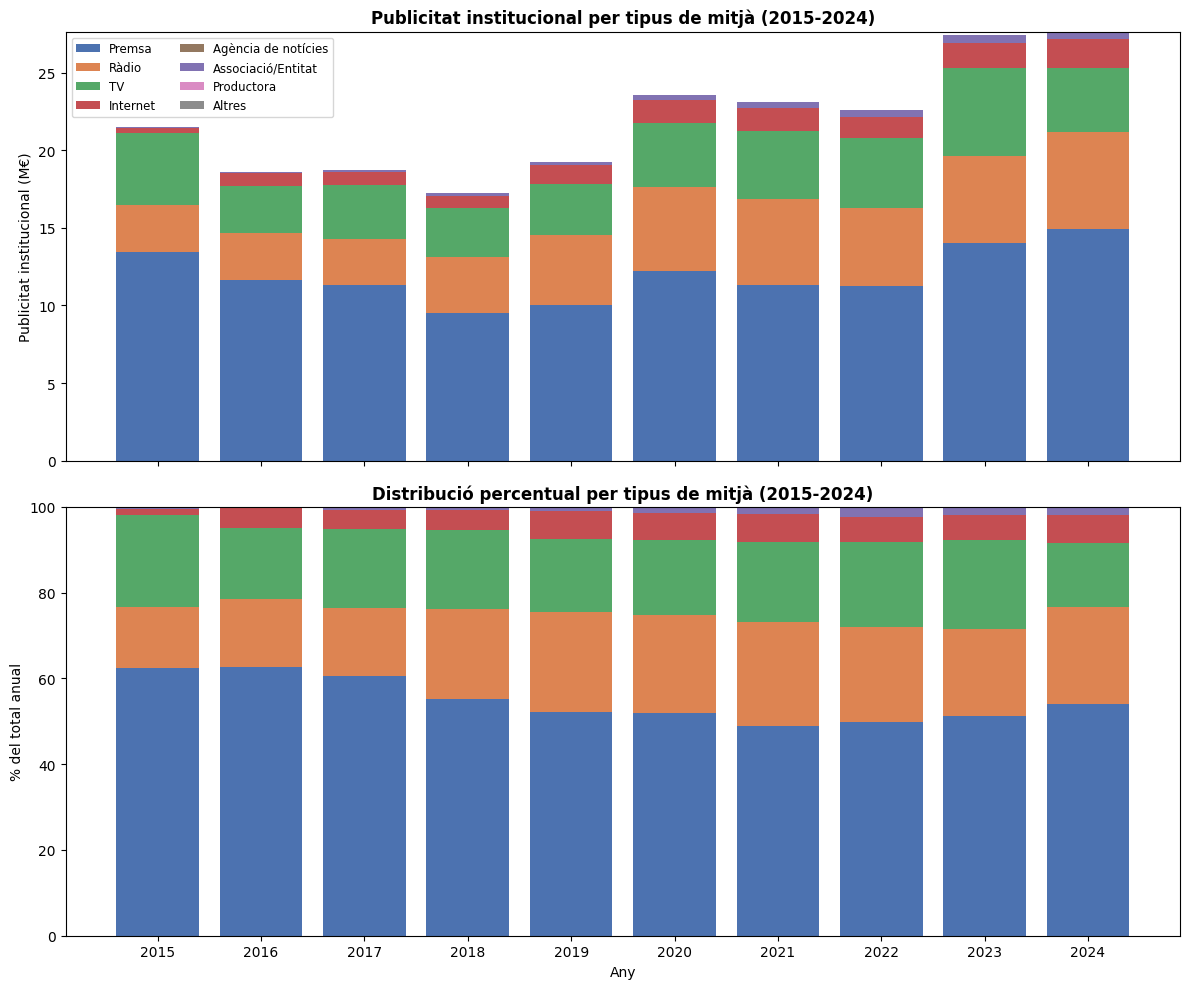

In [9]:
pivot_tipus = df_detall.groupby(['Any', 'Tipus_mitja'])['Pub. institucional'].sum().unstack(fill_value=0)
pivot_pct   = pivot_tipus.div(pivot_tipus.sum(axis=1), axis=0) * 100

colors_map = {
    'Premsa': '#4C72B0', 'Ràdio': '#DD8452', 'TV': '#55A868', 'Internet': '#C44E52',
    'Associació/Entitat': '#8172B2', 'Agència de notícies': '#937860',
    'Productora': '#DA8BC3', 'Altres': '#8C8C8C'
}
cols_ordenades = [c for c in
    ['Premsa', 'Ràdio', 'TV', 'Internet', 'Agència de notícies',
     'Associació/Entitat', 'Productora', 'Altres']
    if c in pivot_tipus.columns]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax = axes[0]
bottom = np.zeros(len(pivot_tipus))
for c in cols_ordenades:
    vals = pivot_tipus[c].values / 1e6
    ax.bar(pivot_tipus.index, vals, bottom=bottom, label=c, color=colors_map.get(c, 'gray'))
    bottom += vals
ax.set_ylabel('Publicitat institucional (M€)')
ax.set_title('Publicitat institucional per tipus de mitjà (2015-2024)', fontweight='bold')
ax.legend(loc='upper left', fontsize=8.5, ncol=2)

ax2 = axes[1]
bottom2 = np.zeros(len(pivot_pct))
for c in cols_ordenades:
    vals = pivot_pct[c].values
    ax2.bar(pivot_pct.index, vals, bottom=bottom2, label=c, color=colors_map.get(c, 'gray'))
    bottom2 += vals
ax2.set_ylabel('% del total anual')
ax2.set_xlabel('Any')
ax2.set_title('Distribució percentual per tipus de mitjà (2015-2024)', fontweight='bold')
ax2.set_xticks(sorted(df_detall['Any'].unique()))

plt.tight_layout()
plt.savefig('g5_evolucio_tipus_mitja.png', dpi=150)
plt.show()

**Interpretació**

Tot i que les audiències i el consum de paper han caigut molt desdes del 2015 a favor dels formats digitals i les xarxes, la gràfica de distribució per formats o grups (com Grupo Godó o Premsa Ibèrica) demostra que la premsa tradicional (paper + les seves rèplica PDF/web) continua acaparant la gran majoria de la inversió pública. La interpretació que es fa està la Generalitat finançant la influència social o està fent de mecenes per evitar la fallida de capçaleres històriques amb grans estructures de redacció?


### 6. Com s'ha distribuit la publicitat institucional entre els grups mediàtics? (2015-2024)

In [10]:
top5_grups = (df_detall.groupby('Grup')['Pub. institucional'].sum()
              .sort_values(ascending=False).head(5).index.tolist())
print('Top 5 grups mediàtics entre 2015 i 2024:', top5_grups)

df_detall['Grup_agrupat'] = df_detall['Grup'].apply(lambda g: g if g in top5_grups else 'Altres')
df_detall['Grup_agrupat'] = df_detall['Grup_agrupat'].fillna('Altres').replace('', 'Altres')

pivot = df_detall.groupby(['Any', 'Grup_agrupat'])['Pub. institucional'].sum().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
ordre = top5_grups + ['Altres']
pivot_pct = pivot_pct[ordre]

Top 5 grups mediàtics entre 2015 i 2024: ['Grup Godó', 'CCMA (Mitjans públics catalans)', 'Prensa Ibérica', 'Diari ARA', 'Hermes Comunicacions (Punt Avui)']


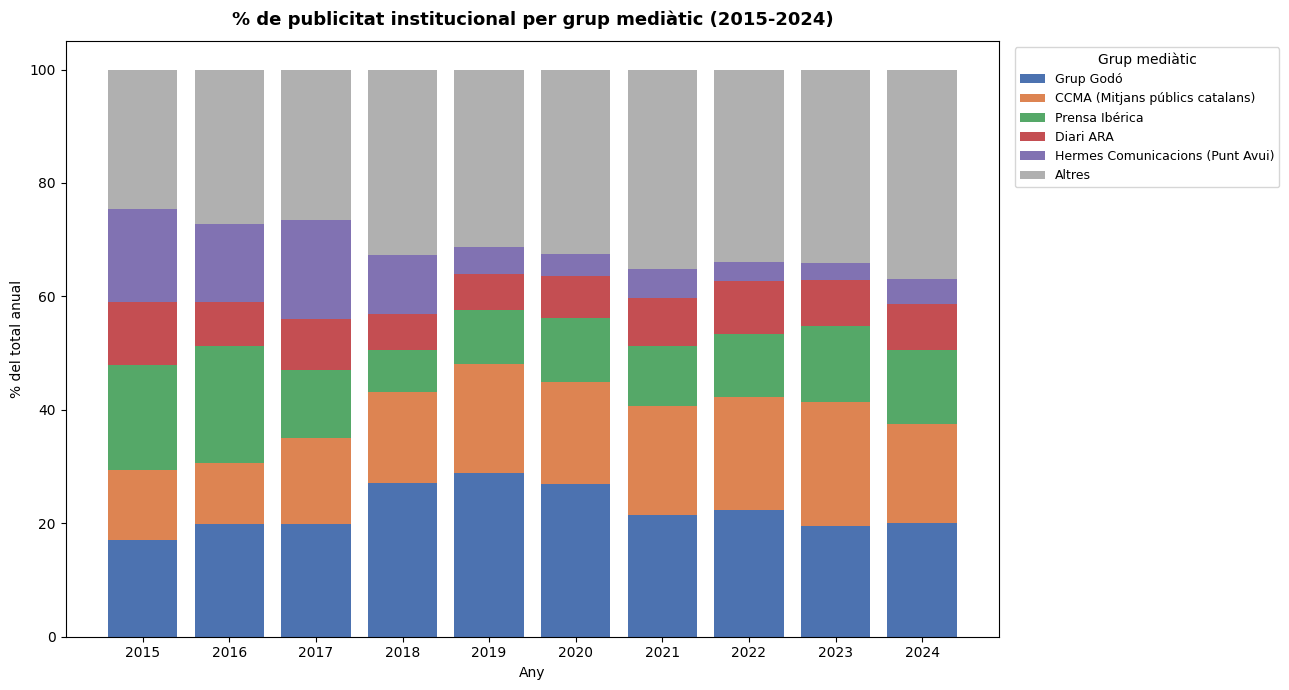

In [11]:
fig, ax = plt.subplots(figsize=(13, 7))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#B0B0B0']
bottom = np.zeros(len(pivot_pct))
for i, grup in enumerate(ordre):
    vals = pivot_pct[grup].values
    ax.bar(pivot_pct.index.astype(str), vals, bottom=bottom, label=grup, color=colors[i])
    bottom += vals

ax.set_title('% de publicitat institucional per grup mediàtic (2015-2024)',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xlabel('Any'); ax.set_ylabel('% del total anual')
ax.set_ylim(0, 105)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, title='Grup mediàtic')
plt.tight_layout()
plt.savefig('g6_barres_apilades_grup.png', dpi=150)
plt.show()

### 7. Quina ha estat l'evolució del pes dels mitjans top en el repartiment de la publicitat institucional en funció de qui hi havia al Govern de la Generalitat?

Cada cel·la mostra quin % del total de publicitat institucional d'aquell
any va anar a parar a aquell mitjà concret. Permet detectar visualment si
hi ha mitjans que guanyen o perden pes de manera sobtada en anys concrets
(possibles punts d'inflexió a creuar amb canvis de govern).

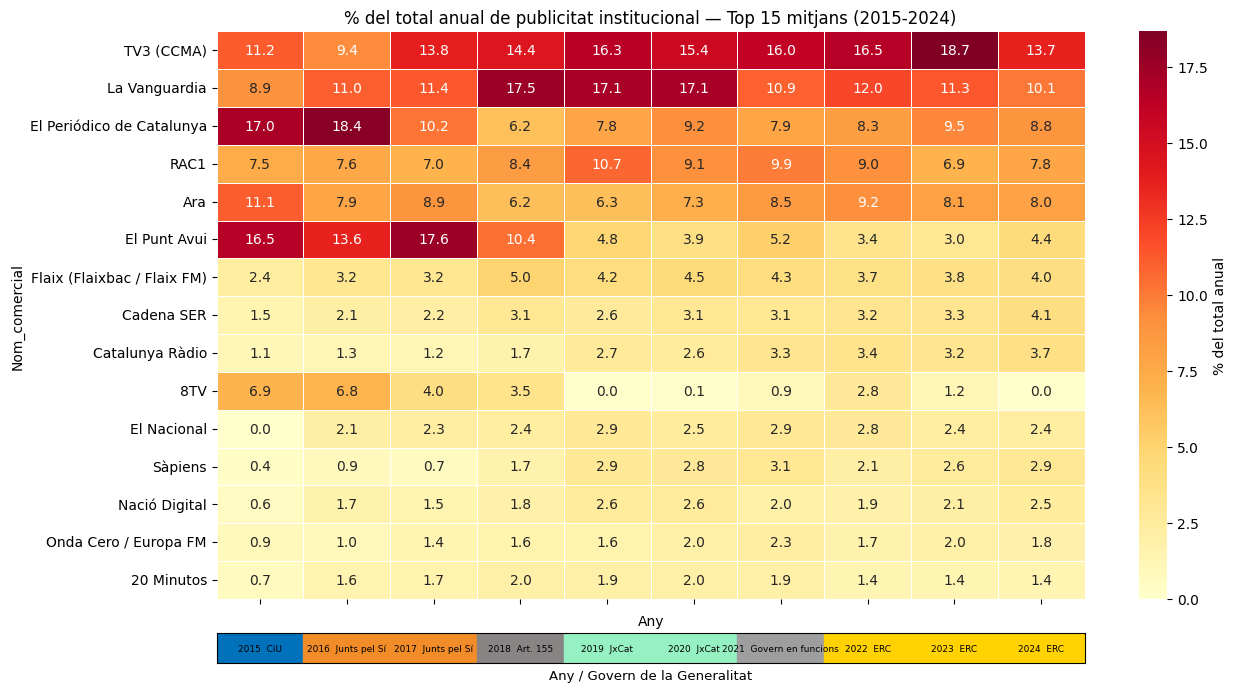

In [12]:
GOVERN_PER_ANY = {
    2015: "CiU (Artur Mas)",
    2016: "Junts pel Sí (Puigdemont, des de gener)",
    2017: "Junts pel Sí (Puigdemont, gen-oct) / Art. 155 (oct-des)",
    2018: "Art. 155 (gen-maig) / JxCat (Torra, des de maig)",
    2019: "JxCat (Torra)",
    2020: "JxCat (Torra, gen-set) / Govern en funcions (set-des)",
    2021: "Govern en funcions (gen-maig) / ERC (Aragonès, des de maig)",
    2022: "ERC (Aragonès)",
    2023: "ERC (Aragonès)",
    2024: "ERC (Aragonès, gen-ago) / PSC (Illa, des d'agost)",
    2025: "PSC (Illa)",
}

def govern_curt(any_):
    text = GOVERN_PER_ANY.get(any_, "")
    return text.split(" (")[0].split(" / ")[0].strip()

# ── Colors de partit (segons especificació) ──
COLOR_GOVERN = {
    "CiU": "#0072BC",                  # blau
    "Junts pel Sí": "#F28C28",         # taronja
    "Art. 155": "#888484",             # fosc
    "JxCat": "#95F1C1",                # verd corporatiu
    "Govern en funcions": "#9E9E9E",   # gris 
    "ERC": "#FFD200",                  # groc
    "PSC": "#E30613",                  # vermell 
}

top15 = (df_detall.groupby('Nom_comercial')['Pub. institucional'].sum()
         .sort_values(ascending=False).head(15).index.tolist())

pivot_h = (df_detall[df_detall['Nom_comercial'].isin(top15)]
           .groupby(['Nom_comercial', 'Any'])['Pub. institucional']
           .sum().unstack(fill_value=0))
pivot_h = pivot_h.reindex(top15)

total_any = df_detall.groupby('Any')['Pub. institucional'].sum()
pivot_pct_h = pivot_h.div(total_any, axis=1) * 100

# Pas 1: dibuixem NOMÉS el heatmap (amb la colorbar inclosa)
fig, ax = plt.subplots(figsize=(14, 8.6))
sns.heatmap(pivot_pct_h, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '% del total anual'}, linewidths=0.4)
ax.set_title("% del total anual de publicitat institucional — Top 15 mitjans (2015-2024)")
ax.set_xticklabels([])

plt.subplots_adjust(bottom=0.22)
fig.canvas.draw()  # força el càlcul de la posició REAL (ja amb la colorbar restada)

# Pas 2: llegim la posició real i EXACTA del heatmap un cop dibuixat
pos = ax.get_position()

# Pas 3: creem la franja fent servir EXACTAMENT la mateixa x0 i amplada
gov_height = 0.035
ax_gov = fig.add_axes([pos.x0, pos.y0 - gov_height - 0.04, pos.width, gov_height])

for i, any_ in enumerate(pivot_pct_h.columns):
    curt = govern_curt(any_)
    color = COLOR_GOVERN.get(curt, "#CCCCCC")
    ax_gov.add_patch(plt.Rectangle((i, 0), 1, 1, color=color))
    ax_gov.text(i+0.5, 0.5, f"{any_}  {curt}", ha='center', va='center', fontsize=6.5)

ax_gov.set_xlim(0, len(pivot_pct_h.columns))
ax_gov.set_ylim(0, 1)
ax_gov.set_yticks([]); ax_gov.set_xticks([])
ax_gov.set_xlabel('Any / Govern de la Generalitat', fontsize=9.5)

plt.savefig('heatmap_top15_govern_alineat.png', dpi=150)

### 8. Existeix concentració en el repartiment de la publicitat institucional i la resta d'ajudes públiques destinat als mitjans? Apliquem la corba de Lorenz i Diagrama de Pareto (2021-2024)

**8a.** Publicitat institucional. 
**8b.** Total d'ajudes públiques
(Subvencions + Contractes + Pub. institucional

In [13]:
def gini(v):
    
    v = np.sort(v[v > 0]); n = len(v) 
    if n == 0: return 0.0
    return (2 * np.sum((np.arange(1, n+1)) * v) - (n+1) * v.sum()) / (n * v.sum()) #

def lorenz_data(v):
    v = np.sort(v[v > 0]); n = len(v)
    cum = np.cumsum(v) / v.sum()    
    x = np.arange(1, n+1) / n  
    return x, cum  

sub2124 = df_detall[(df_detall['Any'] >= 2021) & (df_detall['Any'] <= 2024)]
pub_2124   = sub2124.groupby('Nom_comercial')['Pub. institucional'].sum()

total_2124 = sub2124.groupby('Nom_comercial')['Total'].sum()


gini_pub = gini(pub_2124.values)
gini_tot = gini(total_2124.values)
print(f'Gini Pub. institucional (2021-2024): {gini_pub:.3f}')
print(f'Gini Total ajudes (2021-2024):       {gini_tot:.3f}')

Gini Pub. institucional (2021-2024): 0.693
Gini Total ajudes (2021-2024):       0.823


### 8a. Publicitat institucional

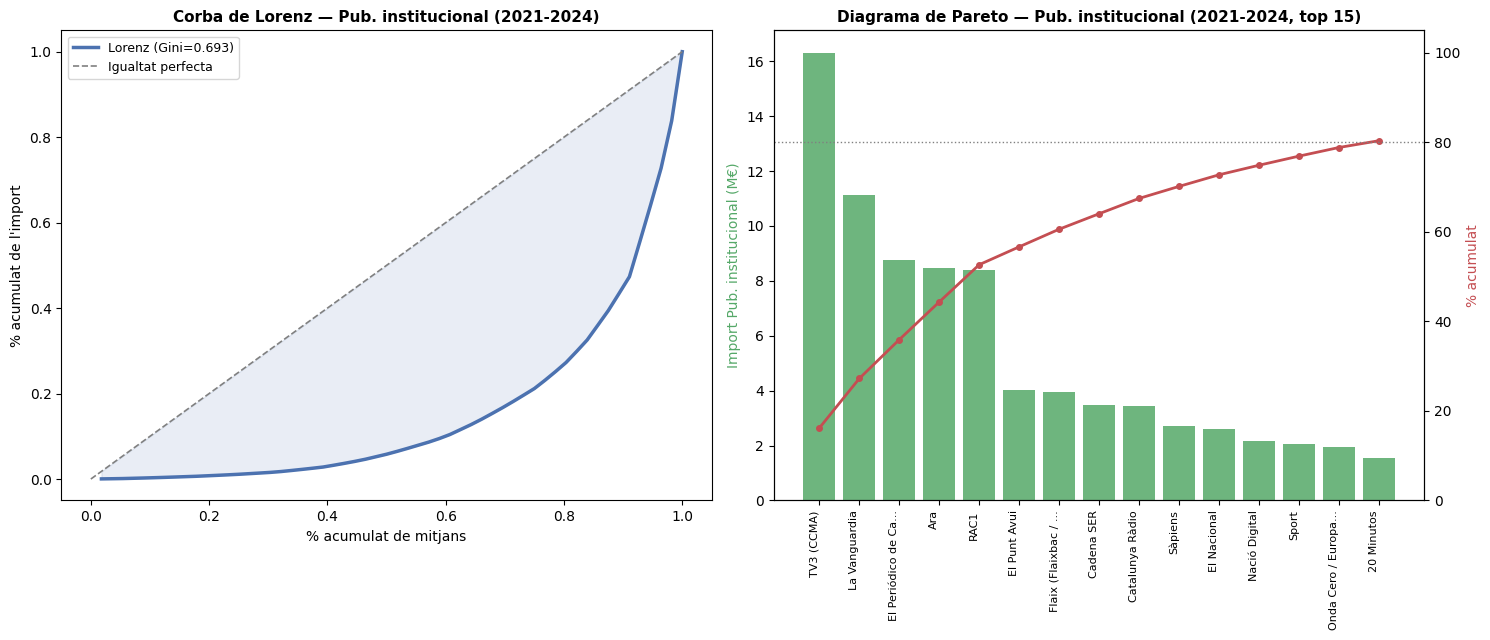

In [14]:

##Corba de Lorenz
x_pub, y_pub = lorenz_data(pub_2124.values) 
                                            

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5)) ##creem figura amb dues subgràfiques

ax = axes[0]
ax.plot(x_pub, y_pub, color='#4C72B0', lw=2.5, label=f'Lorenz (Gini={gini_pub:.3f})') #Dibuixem corba
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.2, label='Igualtat perfecta') ##Dibuixem línia perfecte
ax.fill_between(x_pub, y_pub, x_pub, alpha=0.12, color='#4C72B0') ##Pintem zon entre diagonal i corba
ax.set_title('Corba de Lorenz — Pub. institucional (2021-2024)', fontweight='bold', fontsize=11)
ax.set_xlabel('% acumulat de mitjans'); ax.set_ylabel("% acumulat de l'import")
ax.legend(fontsize=9)


## Diagrama de Pareto
ax2 = axes[1]
pub_sorted = pub_2124.sort_values(ascending=False) #ordenem de major a menor
pub_pct_cum = np.cumsum(pub_sorted.values) / pub_sorted.sum() * 100 ##percentatge acumulat
n_mostrar = min(15, len(pub_sorted)) ##mitjans mostrar
noms_curt = [n[:18] + '...' if len(n) > 18 else n for n in pub_sorted.index[:n_mostrar]]

ax2.bar(range(1, n_mostrar+1), pub_sorted.values[:n_mostrar] / 1e6, color='#55A868', alpha=0.85) ##dibuixem barra dels mitjans
ax2b = ax2.twinx() ##creem segon exi
ax2b.plot(range(1, n_mostrar+1), pub_pct_cum[:n_mostrar], color='#C44E52', marker='o', markersize=4, lw=2)
ax2b.axhline(80, color='gray', linestyle=':', lw=1) ##línia del 80%
ax2b.set_ylim(0, 105)
ax2.set_xticks(range(1, n_mostrar+1))
ax2.set_xticklabels(noms_curt, rotation=90, ha='right', fontsize=8)
ax2.set_ylabel('Import Pub. institucional (M€)', color='#55A868')
ax2b.set_ylabel('% acumulat', color='#C44E52')
ax2.set_title(f'Diagrama de Pareto — Pub. institucional (2021-2024, top {n_mostrar})', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('lorenz_pareto_pubinst.png', dpi=150)
plt.show()

**Interpretació**

En la Corba de Lorenz, com més separada estigui la corba de la diagonal, més desigual és el repartiment. En aquest cas amb un índex de Gini 0.693, ens trobem en un escenari d'altra concentració on la publicitat institucional es reparteix en molt pocs mitjans.
En el diagrama de Pareto podem veure que entre 5 mitjans s'emporten més del 50% de la publicitat institucional, i que entre que 15 s'emporten el 80% de la publicitat institucional

### 8b. Total d'ajudes públiques

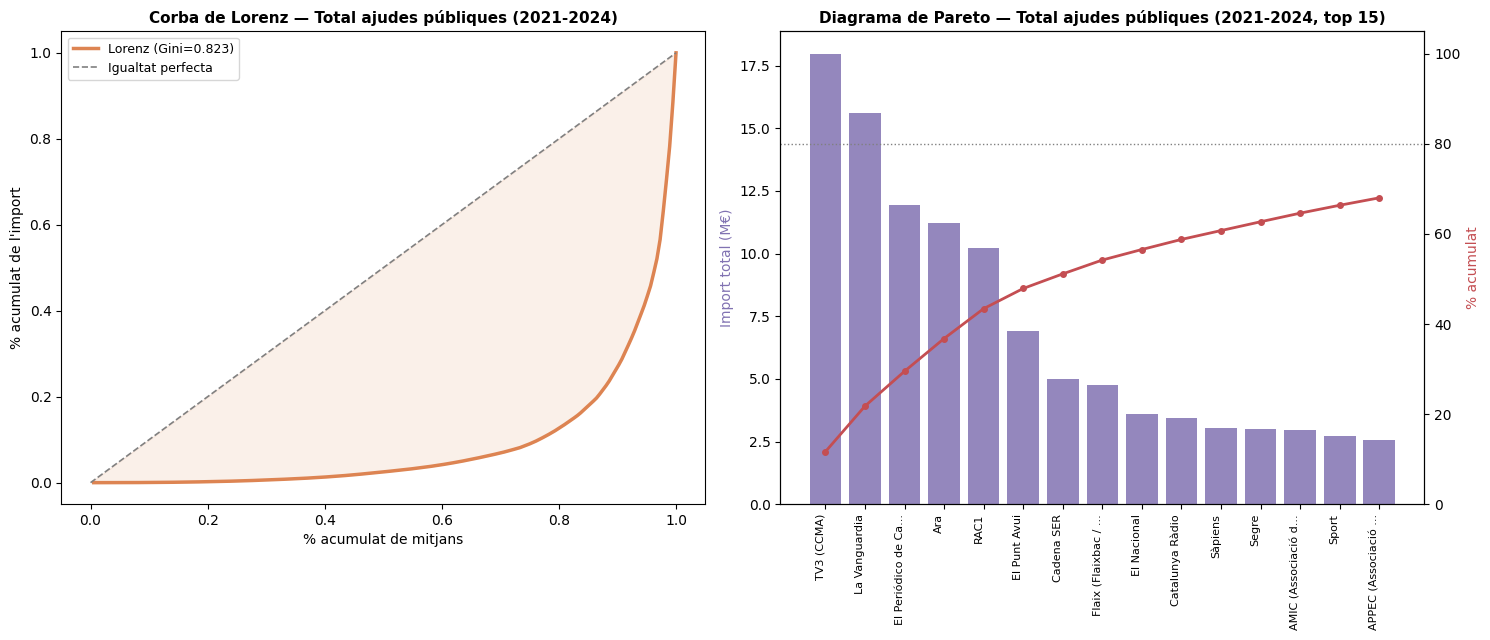

In [15]:
x_tot, y_tot = lorenz_data(total_2124.values)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

ax = axes[0]
ax.plot(x_tot, y_tot, color='#DD8452', lw=2.5, label=f'Lorenz (Gini={gini_tot:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.2, label='Igualtat perfecta')
ax.fill_between(x_tot, y_tot, x_tot, alpha=0.12, color='#DD8452')
ax.set_title('Corba de Lorenz — Total ajudes públiques (2021-2024)', fontweight='bold', fontsize=11)
ax.set_xlabel('% acumulat de mitjans'); ax.set_ylabel("% acumulat de l'import")
ax.legend(fontsize=9)

ax2 = axes[1]
tot_sorted = total_2124.sort_values(ascending=False)
tot_pct_cum = np.cumsum(tot_sorted.values) / tot_sorted.sum() * 100
n_mostrar = min(15, len(tot_sorted))
noms_curt = [n[:18] + '...' if len(n) > 18 else n for n in tot_sorted.index[:n_mostrar]]

ax2.bar(range(1, n_mostrar+1), tot_sorted.values[:n_mostrar] / 1e6, color='#8172B2', alpha=0.85)
ax2b = ax2.twinx()
ax2b.plot(range(1, n_mostrar+1), tot_pct_cum[:n_mostrar], color='#C44E52', marker='o', markersize=4, lw=2)
ax2b.axhline(80, color='gray', linestyle=':', lw=1)
ax2b.set_ylim(0, 105)
ax2.set_xticks(range(1, n_mostrar+1))
ax2.set_xticklabels(noms_curt, rotation=90, ha='right', fontsize=8)
ax2.set_ylabel('Import total (M€)', color='#8172B2')
ax2b.set_ylabel('% acumulat', color='#C44E52')
ax2.set_title(f'Diagrama de Pareto — Total ajudes públiques (2021-2024, top {n_mostrar})', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('lorenz_pareto_total.png', dpi=150)
plt.show()

**Interpretació**

Si sumem els contractes i les subvencions, encara obtenim un índex de Gini encara més gran del 0.823, això indica que els grans grups que s'emporten gran part de la publicitat institucional també s'emporten les altres partides de finançament públic


### 9.Quin és el fluxe de diner públic entre administració i mitjà?

In [16]:
cols_admin = [c for c in df_detall.columns if c.startswith('admin_')]

NOMS_ADMIN = {
    'admin_generalitat':          'Generalitat',
    'admin_diputacio_bcn':        'Diputació de Barcelona',
    'admin_diputacio_girona':     'Diputació de Girona',
    'admin_diputacio_lleida':     'Diputació de Lleida',
    'admin_diputacio_tarragona':  'Diputació de Tarragona',
    'admin_ajuntament_bcn':       'Ajuntament de Barcelona',
    'admin_altres_ajuntaments':   'Altres ajuntaments',
    'admin_estat':                'Estat',
    'admin_altres':               'Altres administracions',
}

COLORS_CONCEPTE = {
    'Subvencions':        'rgba(76,114,176,0.55)',   # blau
    'Contractes':         'rgba(221,132,82,0.55)',   # taronja
    'Pub. institucional': 'rgba(85,168,104,0.55)',   # verd
}

In [17]:
def preparar_sankey_concepte(any_, top_admin=4, top_mitjans=10):
    """
    Retorna {(admin, mitjà, concepte): import} per a un any.
    Reparteix l'import de cada administració entre Subv./Contr./Pub.inst.
    de manera PROPORCIONAL al mix de conceptes de cada mitjà aquell any
    """
    sub = df_detall[df_detall['Any'] == any_].copy()

    totals_admin = sub[cols_admin].sum().sort_values(ascending=False)
    top_admin_cols = totals_admin.head(top_admin).index.tolist()

    totals_mitja = sub.groupby('Nom_comercial')['Total'].sum().sort_values(ascending=False)
    top_mitja_noms = totals_mitja.head(top_mitjans).index.tolist()

    flows = {}
    for _, fila in sub.iterrows():
        total_fila = fila['Total']
        if total_fila <= 0:
            continue

        prop_subv = fila['Subvencions'] / total_fila
        prop_cont = fila['Contractes'] / total_fila
        prop_pub  = fila['Pub. institucional'] / total_fila

        nom = fila['Nom_comercial'] if fila['Nom_comercial'] in top_mitja_noms else 'Altres mitjans'

        for c in cols_admin:
            valor_admin = fila[c]
            if valor_admin <= 0:
                continue
            admin_label = (
                NOMS_ADMIN.get(c, c) if c in top_admin_cols
                else 'Altres administracions (agrupat)'
            )
            for concepte, prop in [
                ('Subvencions', prop_subv),
                ('Contractes', prop_cont),
                ('Pub. institucional', prop_pub)
            ]:
                valor_split = valor_admin * prop
                if valor_split <= 0:
                    continue
                clau = (admin_label, nom, concepte)
                flows[clau] = flows.get(clau, 0) + valor_split

    return flows


def dibuixar_sankey(flows, any_, nom_fitxer):
    """Dibuixa el Sankey amb % als nodes i color per concepte als fluxos."""
    admins = sorted(set(k[0] for k in flows.keys()),
                     key=lambda a: -sum(v for k, v in flows.items() if k[0] == a))
    mitjans = sorted(set(k[1] for k in flows.keys()),
                      key=lambda m: -sum(v for k, v in flows.items() if k[1] == m))

    total_general = sum(flows.values())
    totals_per_admin = {a: sum(v for k, v in flows.items() if k[0] == a) for a in admins}
    totals_per_mitja = {m: sum(v for k, v in flows.items() if k[1] == m) for m in mitjans}

    labels_admin = [f'{a} ({totals_per_admin[a]/total_general*100:.1f}%)' for a in admins]
    labels_mitja = [f'{m} ({totals_per_mitja[m]/total_general*100:.1f}%)' for m in mitjans]
    nodes = labels_admin + labels_mitja
    idx = {n: i for i, n in enumerate(admins + mitjans)}

    colors_admin_node = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
    node_colors = (
        [colors_admin_node[i % len(colors_admin_node)] for i in range(len(admins))]
        + ['#B0B0B0'] * len(mitjans)
    )

    source, target, value, link_colors = [], [], [], []
    for (admin_label, mitja_label, concepte), valor in flows.items():
        source.append(idx[admin_label])
        target.append(idx[mitja_label])
        value.append(valor)
        link_colors.append(COLORS_CONCEPTE[concepte])

    fig = go.Figure(data=[go.Sankey(
        node=dict(pad=15, thickness=18, line=dict(color='black', width=0.5),
                  label=nodes, color=node_colors),
        link=dict(source=source, target=target, value=value, color=link_colors)
    )])
    fig.update_layout(
        title_text=(
            f'Flux Administració → Mitjà per concepte ({any_})<br>'
            f'<sub>Blau=Subvencions · Taronja=Contractes · Verd=Pub. institucional '
            f'| % = pes sobre el total de l\'any (estimació proporcional)</sub>'
        ),
        font_size=11, height=700, width=1050
    )
    fig.write_html(f'{nom_fitxer}.html')
    print(f'Guardat: {nom_fitxer}.html')
    fig.show()
  

In [18]:
flows_2023 = preparar_sankey_concepte(2023)
dibuixar_sankey(flows_2023, 2023, 'sankey_admin_mitja_concepte_2023')

Guardat: sankey_admin_mitja_concepte_2023.html


In [19]:
flows_2024 = preparar_sankey_concepte(2024)
dibuixar_sankey(flows_2024, 2024, 'sankey_admin_mitja_concepte_2024')

Guardat: sankey_admin_mitja_concepte_2024.html


### 10. Tenen relació els ingressos dels mitjans de comunicació i el finançament públic que reben?

Top 25 mitjans per ajudes totals 2023 (amb ingressos ja omplerts):


,Nom_comercial,CIF,Grup,Finançament Public_2023,Ingressos_2023,pct_dependencia
0,TV3 (CCMA),A08849622,CCMA (Mitjans públics catalans),5710902.85,307080000,1.86
1,La Vanguardia,B61475257,Grup Godó,4274070.24,70472460,6.06
2,El Periódico de Catalunya,B66485343,Prensa Ibérica,3895385.75,34000000,11.46
3,Ara,B65258261,Diari ARA,2676079.41,12800000,20.91
4,RAC1,B61726626,Grup Godó,1933189.67,20500000,9.43
5,El Punt Avui,A17374547,Hermes Comunicacions (Punt Avui),1320183.63,6500000,20.31
6,Cadena SER,B28016970,Grupo Prisa,1191126.85,10200000,11.68
7,Flaix (Flaixbac / Flaix FM),B61801635,Flaix (Flaixbac / Flaix FM),1042516.53,4200000,24.82
8,Sport,A08605503,Prensa Ibérica,915897.69,9500000,9.64
9,Catalunya Ràdio,A08846974,CCMA (Mitjans públics catalans),875326.72,68240000,1.28


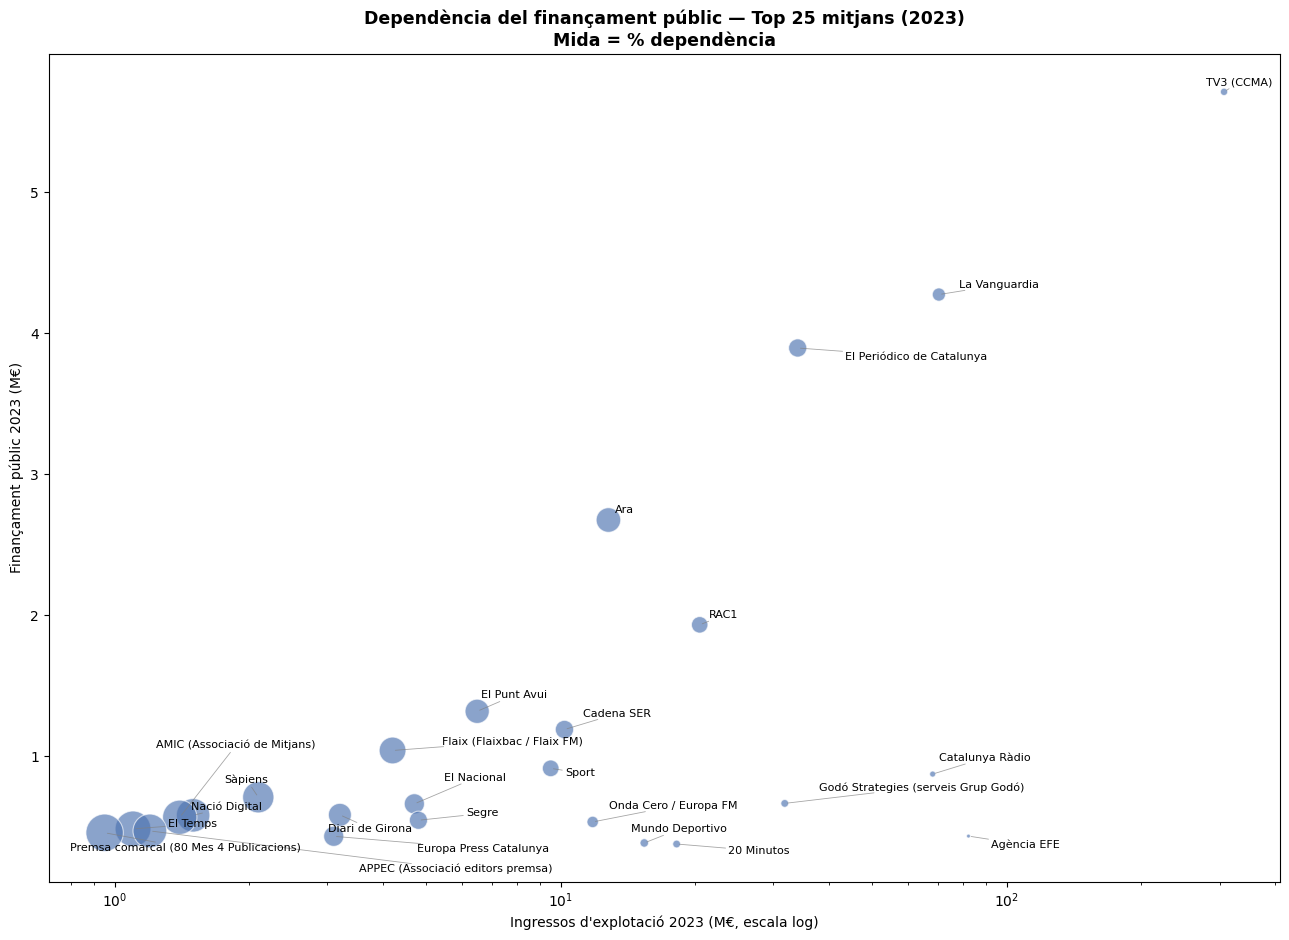

In [20]:
sub23 = df_detall[(df_detall['Any'] == 2023)]

top25 = (sub23.groupby(['Nom_comercial', 'CIF', 'Grup'])['Total']
         .sum().sort_values(ascending=False).head(25)
         .reset_index()
         .rename(columns={'Total': 'Finançament Public_2023'}))

INGRESSOS_2023 = {
    'A08849622': 307080000, 'B61475257': 70472460, 'B66485343': 34000000,
    'B65258261': 12800000, 'B61726626': 20500000, 'A17374547': 6500000,
    'B28016970': 10200000, 'B61801635': 4200000, 'A08605503': 9500000,
    'A08846974': 68240000, 'F64074982': 2100000, 'B08936643': 31800000,
    'B66541947': 4700000, 'A61135521': 3200000, 'B60955564': 1500000,
    'G61514162': 1400000, 'B25275926': 4800000, 'A28782936': 11800000,
    'A43056787': 1100000, 'G58366675': 1200000, 'B65672495': 950000,
    'A28028744': 82100000, 'A08536922': 3100000, 'A59114082': 15400000,
    'B99083966': 18200000,
}
top25['Ingressos_2023'] = top25['CIF'].map(INGRESSOS_2023)
top25['pct_dependencia'] = ((top25['Finançament Public_2023'] / top25['Ingressos_2023']) * 100).round(2)

print('Top 25 mitjans per ajudes totals 2023 (amb ingressos ja omplerts):')
display(top25)

# ── Bubble chart amb etiquetes que no se solapen ──
fig, ax = plt.subplots(figsize=(13, 9.5))

ax.scatter(
    top25['Ingressos_2023'] / 1e6,
    top25['Finançament Public_2023'] / 1e6,
    s=top25['pct_dependencia'] * 15,
    alpha=0.65, color='#4C72B0', edgecolor='white', linewidth=0.8,
)

# En lloc de ax.annotate() amb offset fix, creem els textos primer...
textos = []
for _, fila in top25.iterrows():
    t = ax.text(fila['Ingressos_2023'] / 1e6, fila['Finançament Public_2023'] / 1e6,
                fila['Nom_comercial'], fontsize=8)
    textos.append(t)

ax.set_xscale('log')

# ...i deixem que adjust_text els separi automàticament perquè no se solapin,
# dibuixant una lineta fina cap a la bombolla original quan cal desplaçar-los
adjust_text(
    textos, ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.7),
    expand=(1.4, 1.6),
    force_text=(0.5, 0.7),
    force_static=(0.3, 0.3),
)

ax.set_xlabel("Ingressos d'explotació 2023 (M€, escala log)")
ax.set_ylabel("Finançament públic 2023 (M€)")
ax.set_title("Dependència del finançament públic — Top 25 mitjans (2023)\nMida = % dependència",
             fontweight='bold', fontsize=12.5)

plt.tight_layout()
plt.savefig("bubble_dependencia_2023.png", dpi=150)
plt.show()

**Interpretació**
Els mitjans públics/grans (TV3, Catalunya Ràdio, EFE) tenen dependència baixa perquè els seus ingressos totals són enormes en comparació amb el finançament públic rebut. Altres com Ara, EL Punt Avui i el Periodico, patirien sense el finaçament públic. Mentre que les associacions i mitjans petits, especialitzats o locals (El Temps, APPEC, AMIC, Nació Digital) depenen molt més proporcionalment dels diners públics 

### 11. Tenen relació l'audiència dels mitjans de comunicació i el finançament públic que reben?

Anàlisi combinada: paper (amb web) + digitals natius

És una mostra molt petita de 8 elements afegim les **visites web** dels 4 diaris de paper on hem trobat dades SimilarWeb consistents del mateix període (~maig 2024) — La Vanguardia,El Periódico, Ara i El Punt Avui — i les combinem amb els 4 digitals natius, **tots mesurats amb la mateixa mètrica** (visites web mensuals).

In [21]:
dades_combinat = {
    'La Vanguardia':              {'financament': 3922187.42, 'visites': 6700000,  'tipus': 'Paper (amb web)'},
    'El Periódico de Catalunya':  {'financament': 3418880.27, 'visites': 4100000,  'tipus': 'Paper (amb web)'},
    'Ara':                        {'financament': 3397346.01, 'visites': 6100_000,  'tipus': 'Paper (amb web)'},
    'El Punt Avui':               {'financament': 2481745.94, 'visites':   980200,  'tipus': 'Paper (amb web)'},
    'El Nacional':                {'financament': 1190477.67, 'visites': 25000000, 'tipus': 'Digital natiu'},
    'Nació Digital':              {'financament':  693753.66, 'visites':  6700000, 'tipus': 'Digital natiu'},
    'VilaWeb':                    {'financament':  193923.61, 'visites':  4760_000, 'tipus': 'Digital natiu'},
    'Racó Català':                {'financament':   95746.03, 'visites':    633300, 'tipus': 'Digital natiu'},
}

df_comb = pd.DataFrame(dades_combinat).T.reset_index().rename(columns={'index': 'Mitja'})
df_comb['financament'] = df_comb['financament'].astype(float)
df_comb['visites'] = df_comb['visites'].astype(float)

rho_comb, pval_comb = stats.spearmanr(df_comb['visites'], df_comb['financament'])
print(f'Correlació combinada (n={len(df_comb)}): rho = {rho_comb:.3f}, p-value = {pval_comb:.3f}')
display(df_comb)

Correlació combinada (n=8): rho = 0.275, p-value = 0.509


,Mitja,financament,visites,tipus
0,La Vanguardia,3922187.42,6700000.0,Paper (amb web)
1,El Periódico de Catalunya,3418880.27,4100000.0,Paper (amb web)
2,Ara,3397346.01,6100000.0,Paper (amb web)
3,El Punt Avui,2481745.94,980200.0,Paper (amb web)
4,El Nacional,1190477.67,25000000.0,Digital natiu
5,Nació Digital,693753.66,6700000.0,Digital natiu
6,VilaWeb,193923.61,4760000.0,Digital natiu
7,Racó Català,95746.03,633300.0,Digital natiu


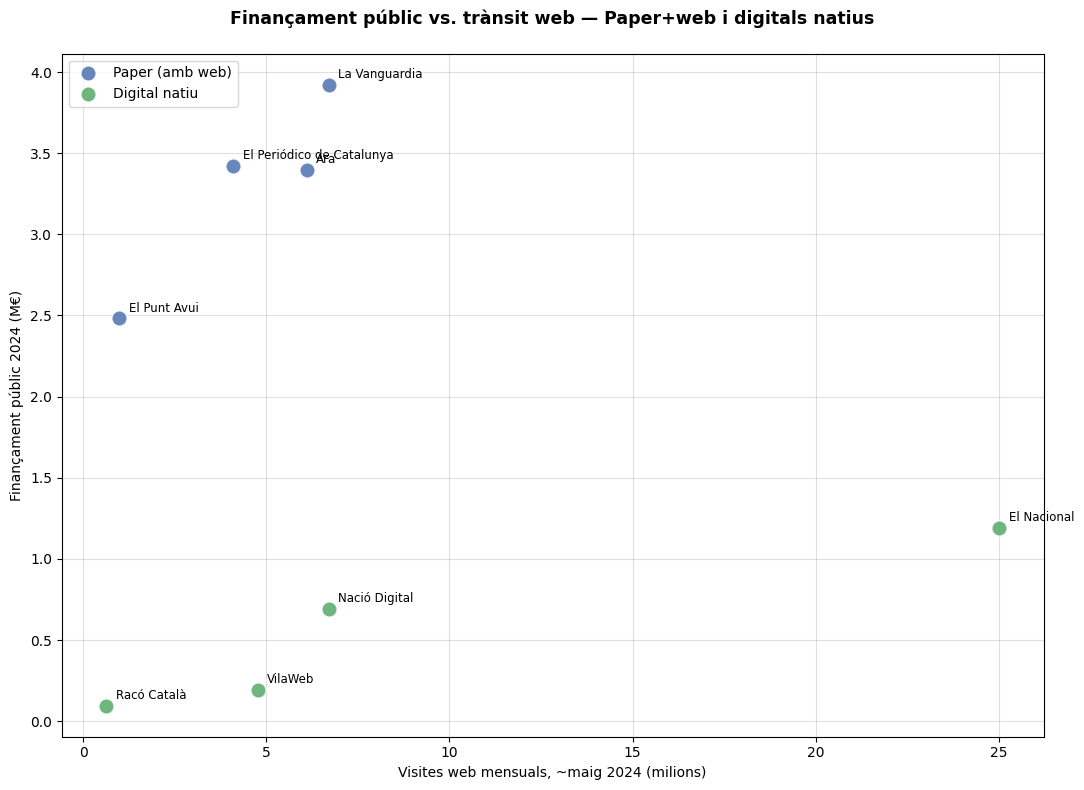

In [22]:
fig, ax = plt.subplots(figsize=(11, 8))
colors = {'Paper (amb web)': '#4C72B0', 'Digital natiu': '#55A868'}

for tipus in df_comb['tipus'].unique():
    sub = df_comb[df_comb['tipus'] == tipus]
    ax.scatter(sub['visites'] / 1e6, sub['financament'] / 1e6, s=120, color=colors[tipus],
               edgecolor='white', linewidth=1, alpha=0.85, zorder=3, label=tipus)

for _, fila in df_comb.iterrows():
    ax.annotate(fila['Mitja'], (fila['visites'] / 1e6, fila['financament'] / 1e6),
                fontsize=8.5, xytext=(7, 5), textcoords='offset points')

ax.set_xlabel('Visites web mensuals, ~maig 2024 (milions)')
ax.set_ylabel('Finançament públic 2024 (M€)')
ax.set_title(
    f'Finançament públic vs. trànsit web — Paper+web i digitals natius\n',
    fontweight='bold', fontsize=12.5
)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('correlacio_combinada_n8.png', dpi=150)
plt.show()

**Interpretació**

El resultat de la correlació de Spearman (no mira valors, mira ordre) combinat (n=8) cau al quadrant "rho baix + p-value alt": una relació ja de per si feble (0,275), hi ha una lleugera tendència que els mitjans amb més audiència rebin més diners, però és una tendència molt fluixa, amb moltes excepcions. i a sobre no podem confiar que sigui real i no pur atzar (0,509)